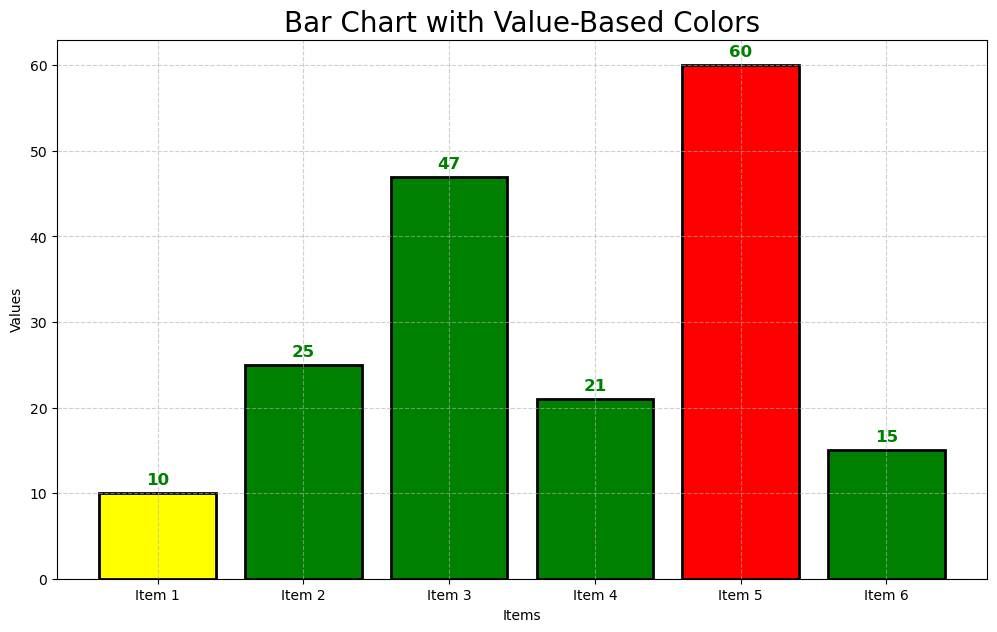

In [ ]:
# sns.histplot(data = penguins,x = 'body_mass_g’)
import matplotlib.pyplot as plt
import numpy as np

# Example list (replace with your own list if needed)
values = [10, 25, 47, 21, 60, 15]

# X-axis labels
labels = [f"Item {i+1}" for i in range(len(values))]

plt.figure(figsize=(12,7))

# Determine thresholds
max_val = max(values)
min_val = min(values)
avg_val = np.mean(values)

colors = []
for v in values:
    if v == max_val:
        colors.append('red')        # high
    elif v == min_val:
        colors.append('yellow')     # low
    else:
        colors.append('green')      # average

# Plot bars
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=2)

# Add bold labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        str(height),
        ha='center',
        fontsize=12,
        fontweight='bold',
        color='green'
    )

# Titles and labels
plt.title("Bar Chart with Value-Based Colors", fontsize=20)
plt.xlabel("Items")
plt.ylabel("Values")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


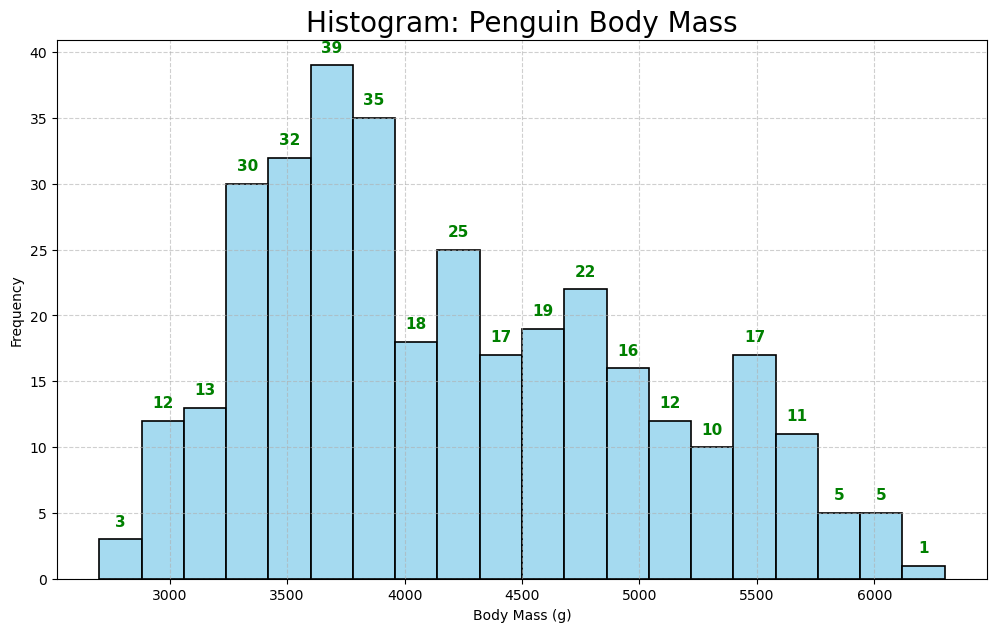

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
penguins = sns.load_dataset("penguins")

plt.figure(figsize=(12,7))

# Create histogram using seaborn
hist = sns.histplot(
    data=penguins,
    x='body_mass_g',
    bins=20,
    color='skyblue',
    edgecolor='black',
    linewidth=1.2
)

# Extract bin counts and edges from matplotlib
counts, bin_edges = np.histogram(penguins['body_mass_g'].dropna(), bins=20)

# Add labels on each bar
for count, edge in zip(counts, bin_edges[:-1]):
    plt.text(
        edge + (bin_edges[1] - bin_edges[0]) / 2,   # center of bin
        count + 1,                                  # slightly above bar
        str(count),
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='green'
    )

# Titles and labels
plt.title('Histogram: Penguin Body Mass', fontsize=20)
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()



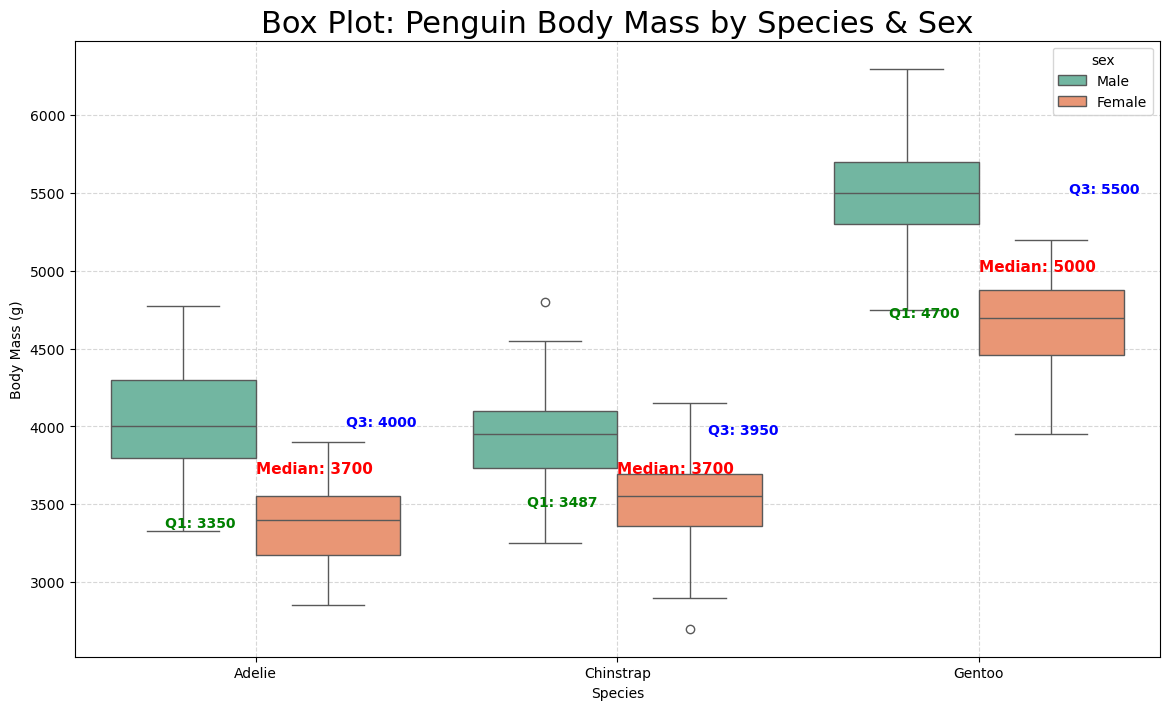

In [9]:
# sns.boxplot(data = penguins, x = 'species', y = 'body_mass_g' , hue = 'sex')
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
penguins = sns.load_dataset("penguins")

plt.figure(figsize=(14,8))

# Box plot
sns.boxplot(
    data=penguins,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette='Set2'
)

# Compute and label percentiles for each species
species_list = penguins['species'].unique()

for i, sp in enumerate(species_list):
    sp_data = penguins[penguins['species'] == sp]['body_mass_g'].dropna()

    q1 = np.percentile(sp_data, 25)
    median = np.percentile(sp_data, 50)
    q3 = np.percentile(sp_data, 75)

    # Label Q1, Median, Q3
    plt.text(
        i - 0.25, q1,
        f"Q1: {int(q1)}",
        fontsize=10,
        fontweight='bold',
        color='green'
    )
    plt.text(
        i, median,
        f"Median: {int(median)}",
        fontsize=11,
        fontweight='bold',
        color='red'
    )
    plt.text(
        i + 0.25, q3,
        f"Q3: {int(q3)}",
        fontsize=10,
        fontweight='bold',
        color='blue'
    )

# Titles and labels
plt.title("Box Plot: Penguin Body Mass by Species & Sex", fontsize=22)
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


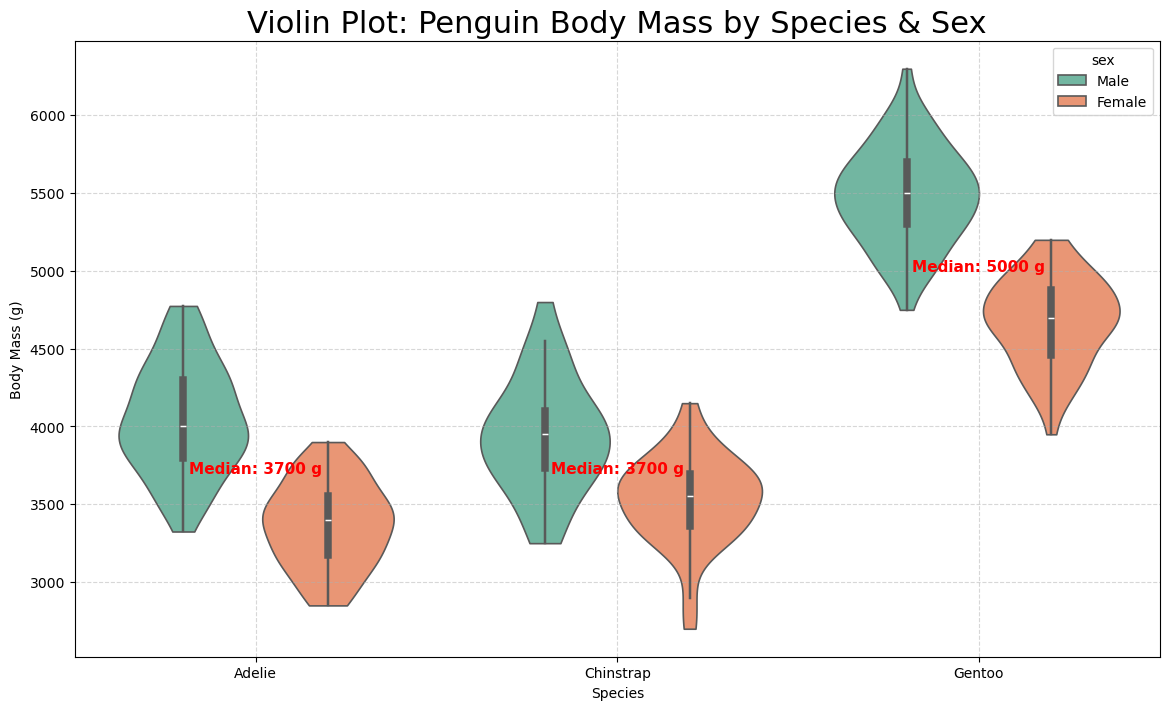

In [10]:
# sns.violinplot(data = penguins, x = 'species', y = 'body_mass_g' , hue = 'sex')
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
penguins = sns.load_dataset("penguins")

plt.figure(figsize=(14,8))

# Violin plot
sns.violinplot(
    data=penguins,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette='Set2',
    cut=0,
    linewidth=1.2
)

# Add intuitive labels: median for each species
species_list = penguins['species'].unique()

for i, sp in enumerate(species_list):
    sp_data = penguins[penguins['species'] == sp]['body_mass_g'].dropna()
    median = np.median(sp_data)

    plt.text(
        i, median,
        f"Median: {int(median)} g",
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='red'
    )

# Titles and labels
plt.title("Violin Plot: Penguin Body Mass by Species & Sex", fontsize=22)
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()



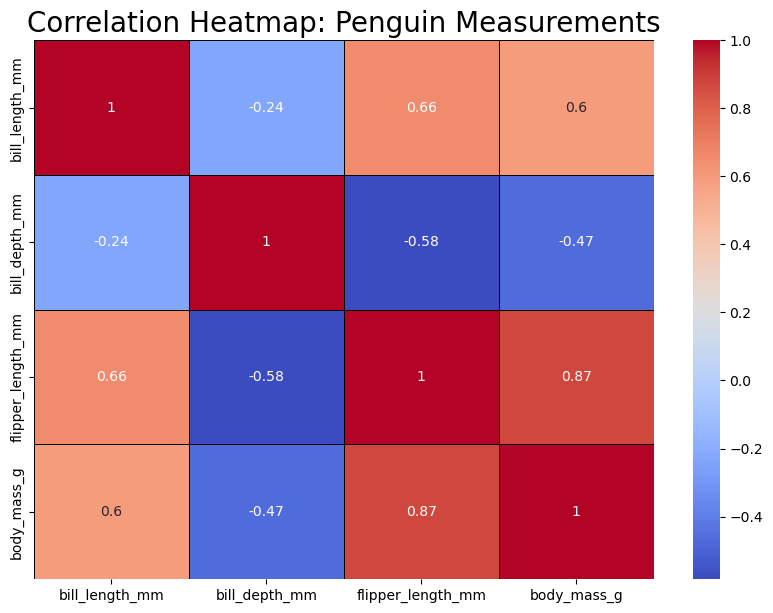

In [12]:
# columns = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']sns.heatmap(data = penguins[columns].corr(), annot = True, cmap = 'coolwarm')
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
columns = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']

plt.figure(figsize=(10,7))

sns.heatmap(
    data=penguins[columns].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black'
)

plt.title("Correlation Heatmap: Penguin Measurements", fontsize=20)
plt.show()


In [13]:
#  given data and analyze the data using violin plot 
import pandas as pd

# 1. Load datasets
import pandas as pd

# Load all datasets
store_df = pd.read_csv("store_data.csv")
sales_df = pd.read_csv("sales_data.csv")
product_df = pd.read_csv("product_data.csv")
customer_df = pd.read_csv("customer_data.csv")

# Clean store_df column names
store_df.columns = (
    store_df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('[^a-zA-Z0-9_]', '', regex=True)
)


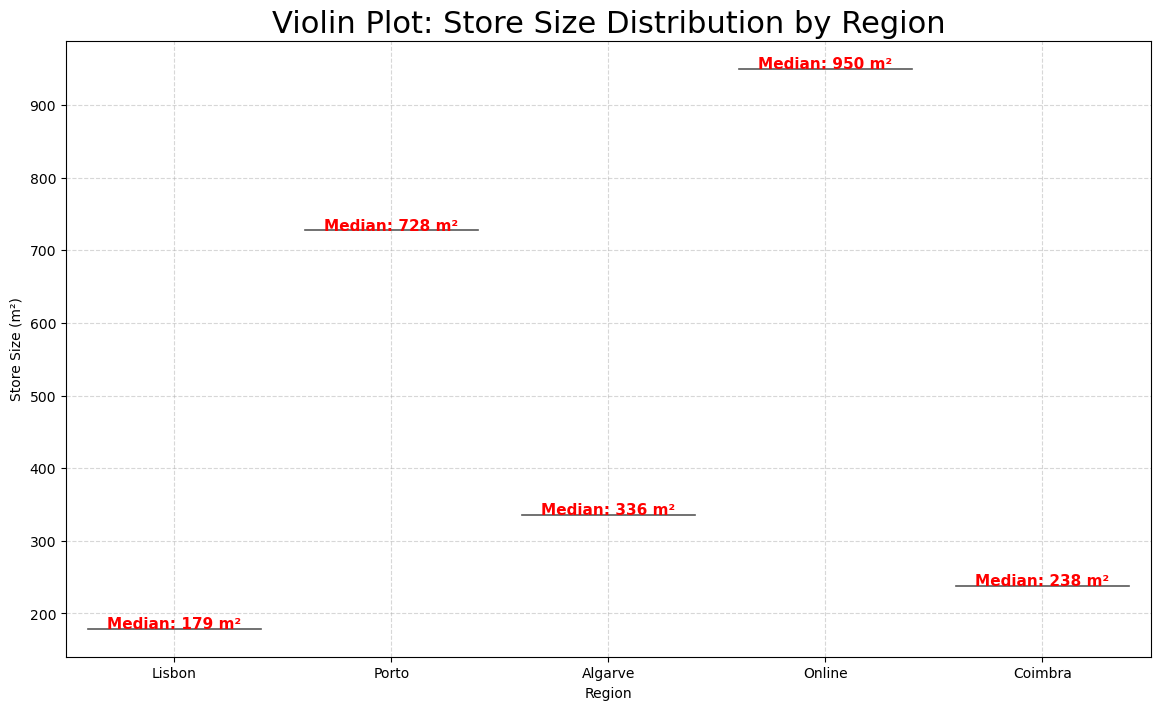

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,8))

sns.violinplot(
    data=store_df,
    x='region',
    y='store_size_m2',
    hue='region',          # <-- FIX: assign palette to hue
    palette='Set2',
    cut=0,
    linewidth=1.2,
    legend=False           # <-- remove duplicate legend
)

# Add median labels
regions = store_df['region'].unique()

for i, reg in enumerate(regions):
    reg_data = store_df[store_df['region'] == reg]['store_size_m2'].dropna()
    median = np.median(reg_data)

    plt.text(
        i,
        median,
        f"Median: {int(median)} m²",
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='red'
    )

plt.title("Violin Plot: Store Size Distribution by Region", fontsize=22)
plt.xlabel("Region")
plt.ylabel("Store Size (m²)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()





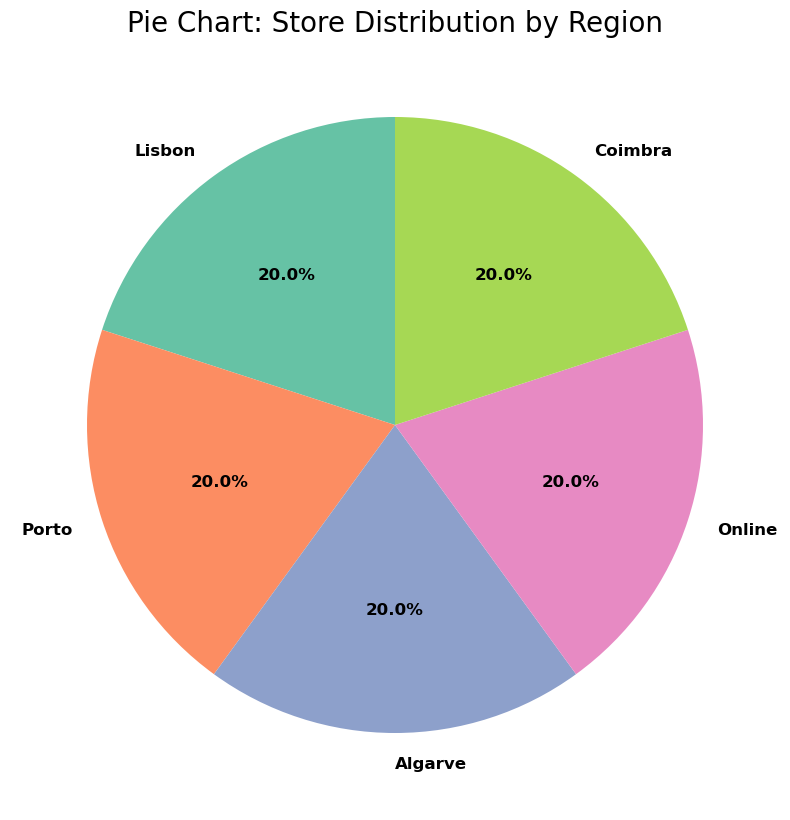

In [24]:
# sns pie chart, Store Count by Region
import seaborn as sns
import matplotlib.pyplot as plt

# Count stores per region
region_counts = store_df['region'].value_counts()

plt.figure(figsize=(10,10))

plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2", len(region_counts)),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title("Pie Chart: Store Distribution by Region", fontsize=20)
plt.show()


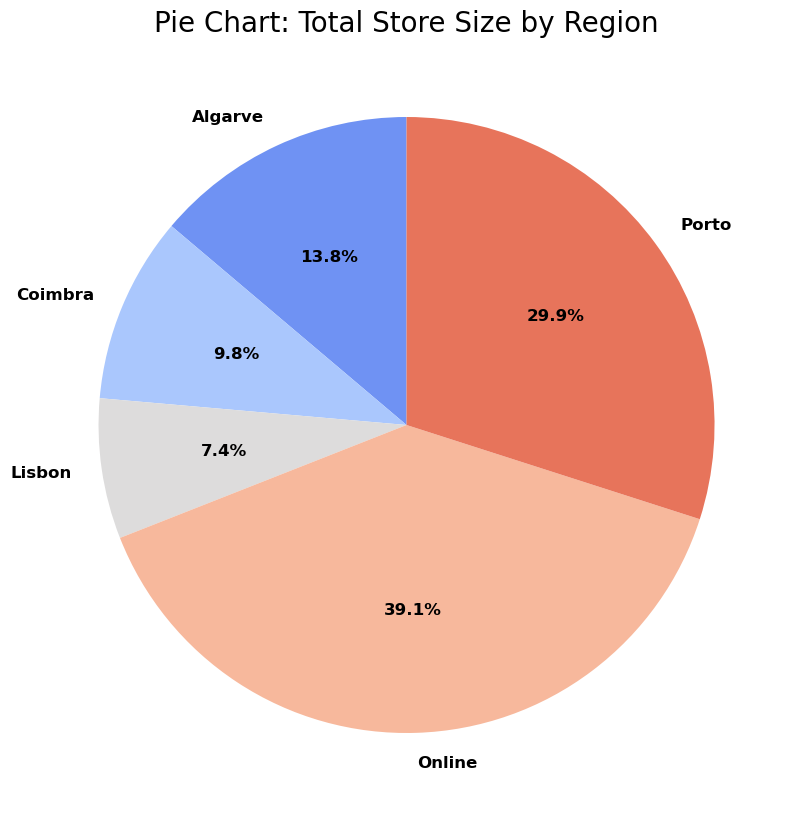

In [25]:
# Total Store Size by Region
import seaborn as sns
import matplotlib.pyplot as plt

# Sum store sizes per region
region_sizes = store_df.groupby('region')['store_size_m2'].sum()

plt.figure(figsize=(10,10))

plt.pie(
    region_sizes,
    labels=region_sizes.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("coolwarm", len(region_sizes)),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title("Pie Chart: Total Store Size by Region", fontsize=20)
plt.show()
